
# Tech Assessment: Weather Trend Forecasting
**Role:** AI Engineer Intern + Data Science Intern (Dual Role)
**Author:** Tomás Ignacio Nadal

> **PM Accelerator Mission:** The Product Manager Accelerator is a premier program designed to help professionals transition into and accelerate their careers in product management. Our mission is to empower individuals with the skills, network, and experience needed to succeed in tech.

---
## Objective
Analyze the `GlobalWeatherRepository.csv` dataset to forecast future weather trends using advanced Machine Learning techniques (Prophet, XGBoost, Random Forest Ensembles), anomaly detection, and environmental analysis.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)


Importing plotly failed. Interactive plots will not work.


## 1. Data Cleaning & Preprocessing (Normalization)

In [2]:

# Load dataset
df = pd.read_csv('data/GlobalWeatherRepository.csv')

# Parse dates
df['last_updated'] = pd.to_datetime(df['last_updated'])

# Drop duplicates if any
df = df.drop_duplicates()

# Handle missing values: Forward fill for time series consistency
df = df.sort_values(by=['country', 'location_name', 'last_updated'])
df = df.ffill().bfill()

# Feature Engineering: Temporal Features
df['hour'] = df['last_updated'].dt.hour
df['month'] = df['last_updated'].dt.month

# Data Normalization
features_to_normalize = ['wind_mph', 'pressure_mb', 'precip_mm', 'humidity', 'cloud', 'uv_index', 'latitude', 'longitude', 'hour', 'month']
scaler = StandardScaler()
df[features_to_normalize] = scaler.fit_transform(df[features_to_normalize])

print(f"Dataset Shape: {df.shape}")
display(df.head())


Dataset Shape: (152997, 43)


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,hour,month
0,Afghanistan,Kabul,0.626181,0.719028,Asia/Kabul,1715849100,2024-05-16 13:15:00,26.6,79.8,Partly Cloudy,...,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55,0.488537,-0.448633
195,Afghanistan,Kabul,0.626181,0.719028,Asia/Kabul,1715868000,2024-05-16 18:30:00,22.0,71.6,Patchy rain nearby,...,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55,1.536263,-0.448633
390,Afghanistan,Kabul,0.626181,0.719028,Asia/Kabul,1715961600,2024-05-17 20:30:00,15.0,58.9,Patchy rain nearby,...,1,1,04:49 AM,06:51 PM,01:09 PM,01:37 AM,Waxing Gibbous,64,1.955354,-0.448633
583,Afghanistan,Kabul,0.626181,0.719028,Asia/Kabul,1716042600,2024-05-18 19:00:00,19.5,67.1,Clear,...,1,1,04:48 AM,06:51 PM,02:04 PM,02:00 AM,Waxing Gibbous,73,1.745808,-0.448633
776,Afghanistan,Kabul,0.626181,0.719028,Asia/Kabul,1716127200,2024-05-19 18:30:00,16.9,62.4,Patchy rain nearby,...,1,1,04:48 AM,06:52 PM,03:00 PM,02:22 AM,Waxing Gibbous,81,1.536263,-0.448633


## 2. Advanced Exploratory Data Analysis (EDA) & Anomaly Detection
Visualizing Temperature, Precipitation, and Feature Correlations.

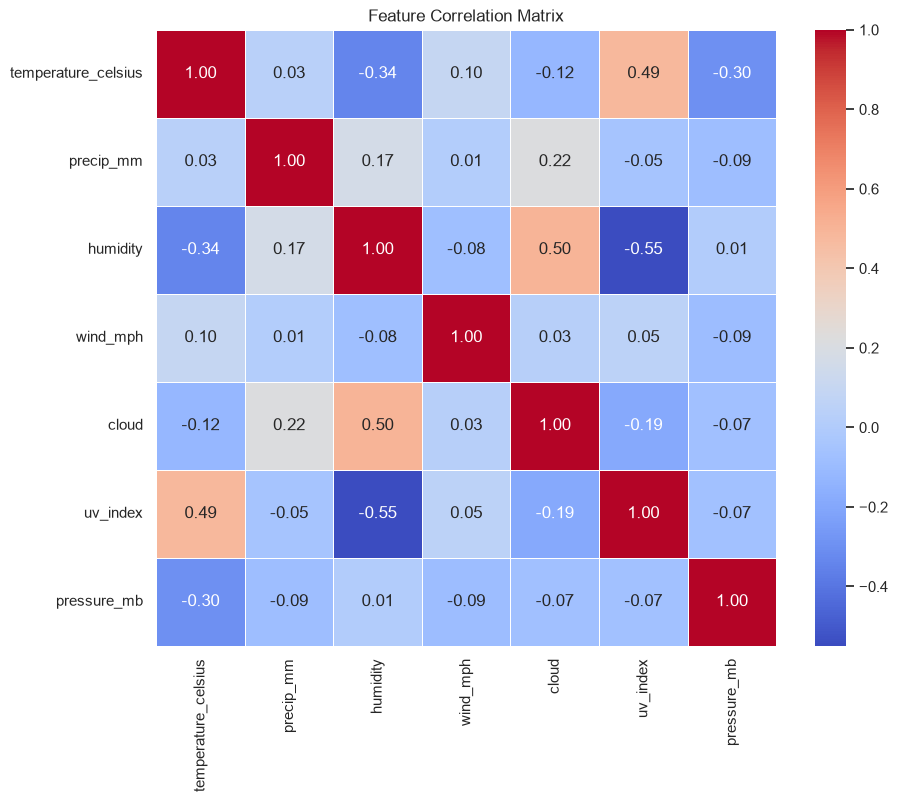

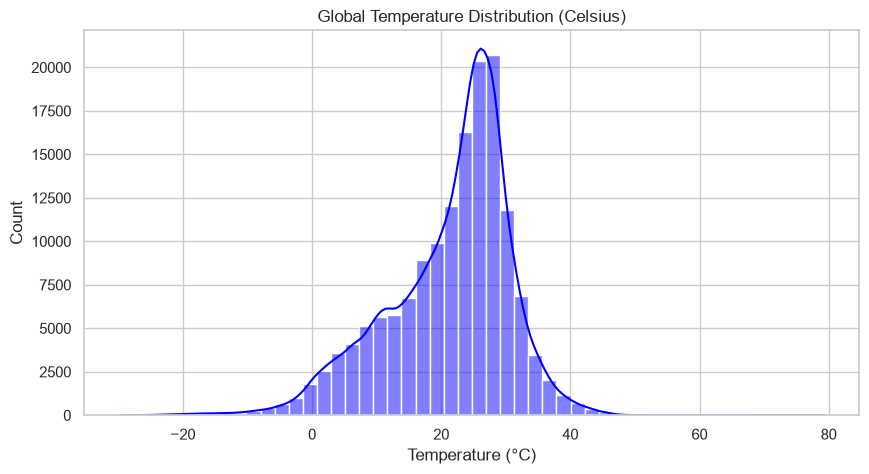

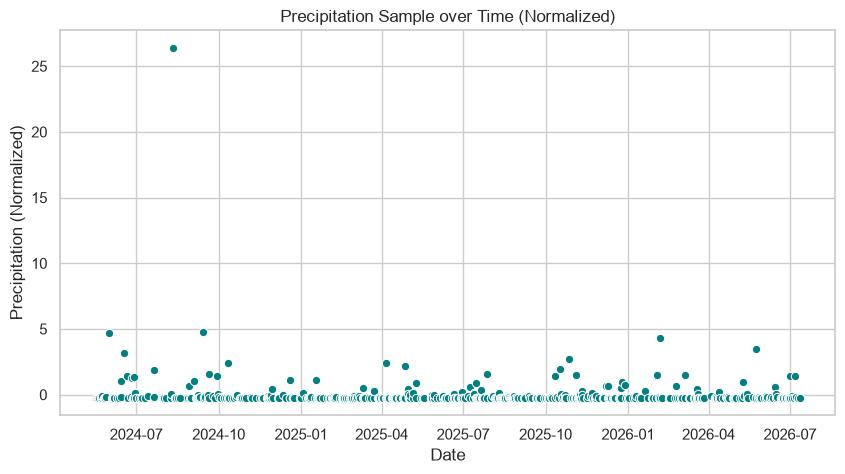

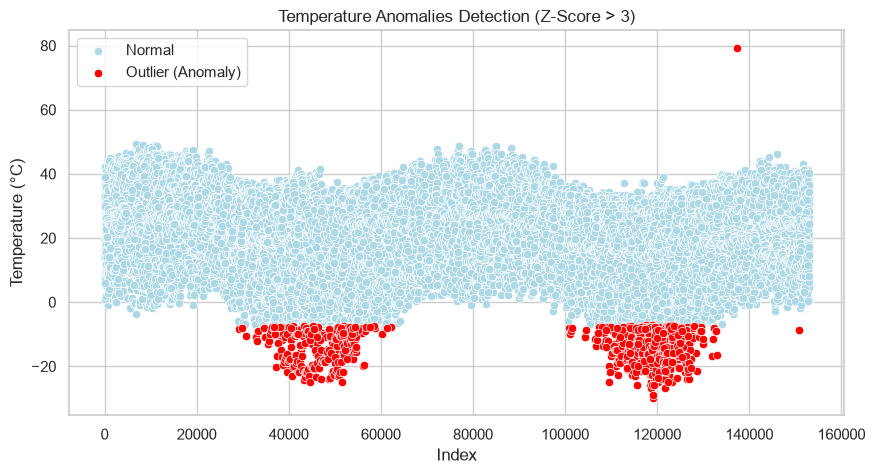

Number of Extreme Temperature Anomalies detected: 994


In [3]:

# Correlation Matrix
plt.figure(figsize=(10, 8))
corr_cols = ['temperature_celsius', 'precip_mm', 'humidity', 'wind_mph', 'cloud', 'uv_index', 'pressure_mb']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

# Temperature Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['temperature_celsius'], bins=50, kde=True, color='blue')
plt.title('Global Temperature Distribution (Celsius)')
plt.xlabel('Temperature (°C)')
plt.show()

# Precipitation Analysis
plt.figure(figsize=(10, 5))
sns.lineplot(data=df.sample(500), x='last_updated', y='precip_mm', color='teal', marker='o', linestyle='')
plt.title('Precipitation Sample over Time (Normalized)')
plt.xlabel('Date')
plt.ylabel('Precipitation (Normalized)')
plt.show()

# Anomaly Detection using Z-Score for temperatures
df['temp_zscore'] = (df['temperature_celsius'] - df['temperature_celsius'].mean()) / df['temperature_celsius'].std()
outliers = df[df['temp_zscore'].abs() > 3]

plt.figure(figsize=(10, 5))
sns.scatterplot(x=df.index, y=df['temperature_celsius'], color='lightblue', label='Normal')
sns.scatterplot(x=outliers.index, y=outliers['temperature_celsius'], color='red', label='Outlier (Anomaly)')
plt.title('Temperature Anomalies Detection (Z-Score > 3)')
plt.xlabel('Index')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

print(f"Number of Extreme Temperature Anomalies detected: {len(outliers)}")


## 3. Unique Analysis: Spatial Patterns & Environmental Impact (Air Quality)
Mapping global temperatures and analyzing Air Quality vs Weather.

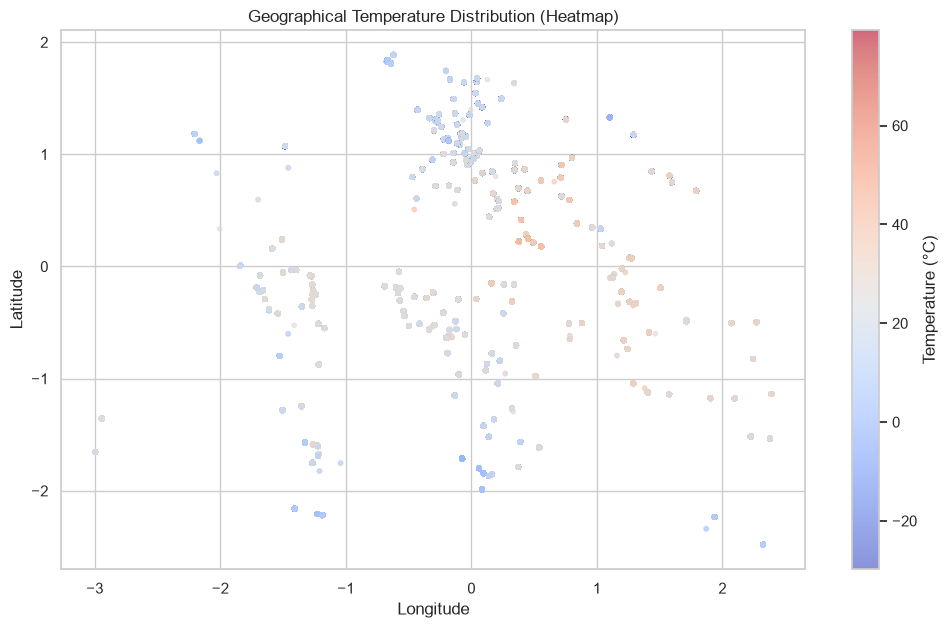

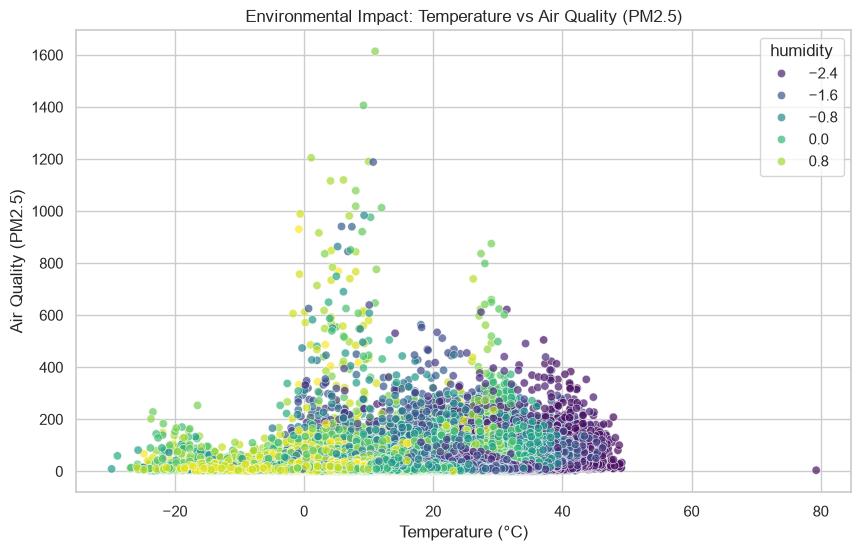

In [4]:

# Geographical Patterns
plt.figure(figsize=(12, 7))
scatter = plt.scatter(df['longitude'], df['latitude'], c=df['temperature_celsius'], cmap='coolwarm', alpha=0.6, s=10)
plt.colorbar(scatter, label='Temperature (°C)')
plt.title('Geographical Temperature Distribution (Heatmap)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# Environmental Impact (Air Quality vs Temperature)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='temperature_celsius', y='air_quality_PM2.5', hue='humidity', palette='viridis', alpha=0.7)
plt.title('Environmental Impact: Temperature vs Air Quality (PM2.5)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Air Quality (PM2.5)')
plt.show()


## 4. Forecasting Model 1: Prophet (Univariate Time Series)
We will aggregate global daily temperatures to forecast general global trends.

15:53:06 - cmdstanpy - INFO - Chain [1] start processing


15:53:06 - cmdstanpy - INFO - Chain [1] done processing


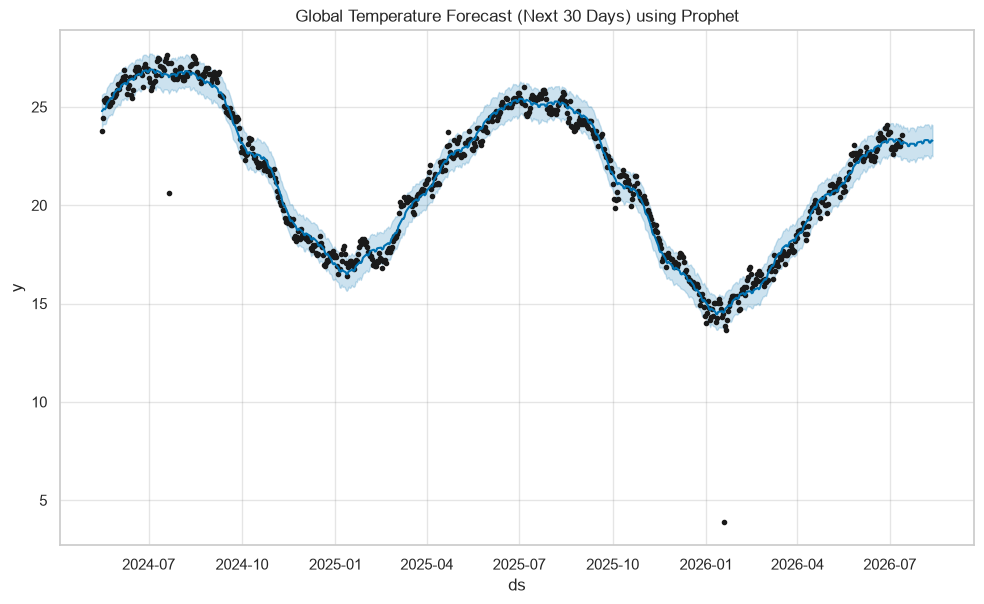

In [5]:

# Aggregate daily average global temperature
daily_temp = df.groupby(df['last_updated'].dt.date)['temperature_celsius'].mean().reset_index()
daily_temp.columns = ['ds', 'y']

# Initialize and fit Prophet
model_prophet = Prophet(daily_seasonality=True)
model_prophet.fit(daily_temp)

# Create future dataframe (forecast next 30 days)
future = model_prophet.make_future_dataframe(periods=30)
forecast = model_prophet.predict(future)

# Plot forecast
fig1 = model_prophet.plot(forecast)
plt.title('Global Temperature Forecast (Next 30 Days) using Prophet')
plt.show()


## 5. Forecasting Model 2: Advanced Ensemble (XGBoost + Random Forest)
Using an Ensemble Voting Regressor to combine the strengths of multiple ML algorithms for maximum accuracy.

Ensemble Model (XGBoost + Random Forest) Performance:
RMSE: 2.65 °C
MAE:  1.96 °C


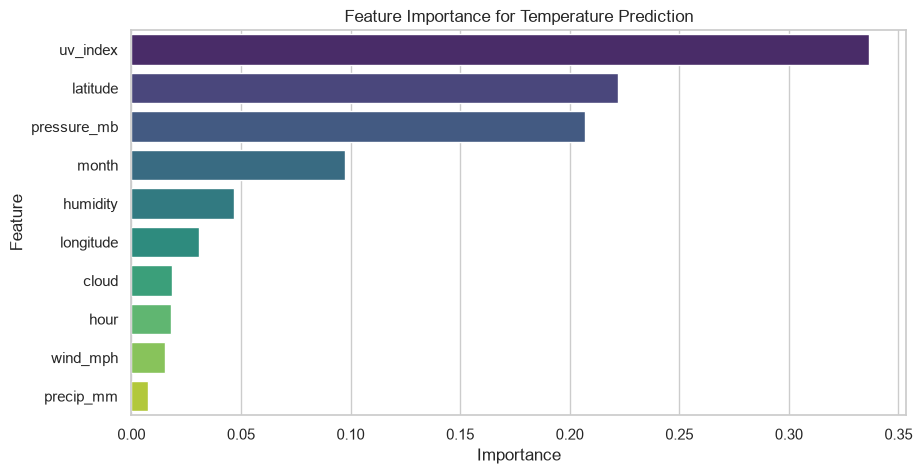

In [6]:

# Features are already normalized
features = ['wind_mph', 'pressure_mb', 'precip_mm', 'humidity', 'cloud', 'uv_index', 'latitude', 'longitude', 'hour', 'month']
target = 'temperature_celsius'

X = df[features]
y = df[target]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define Base Models
xgb_base = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
rf_base = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)

# Create Ensemble Model
ensemble_model = VotingRegressor(estimators=[('xgb', xgb_base), ('rf', rf_base)])
ensemble_model.fit(X_train, y_train)

# Predict and Evaluate
y_pred = ensemble_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"Ensemble Model (XGBoost + Random Forest) Performance:")
print(f"RMSE: {rmse:.2f} °C")
print(f"MAE:  {mae:.2f} °C")

# Unique Analysis: Feature Importance (From XGBoost Base)
xgb_base.fit(X_train, y_train) # Fit standalone to extract importance
importance = xgb_base.feature_importances_
feature_imp = pd.DataFrame({'Feature': features, 'Importance': importance}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feature_imp, palette='viridis')
plt.title('Feature Importance for Temperature Prediction')
plt.show()
